In [2]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from bs4 import BeautifulSoup
import requests
import time
import matplotlib.pyplot as plt
from tensorflow.keras.layers import BatchNormalization
from keras.regularizers import l2
from tensorflow.keras.utils import plot_model
from keras.callbacks import ReduceLROnPlateau
import os 
import http.server
import socketserver
from urllib.parse import parse_qs

In [3]:

start_time = time.time()
# 新的特徵提取函數
def extract_features(url):
    try:
        print(f"Processing URL: {url}")  
        parsed_url = urlparse(url)
        hostname = parsed_url.netloc
        path = parsed_url.path
        query = parsed_url.query
        tld = hostname.split('.')[-1] if '.' in hostname else ''
        features = {
            'url_length': len(url),
            'domain_length': len(parsed_url.netloc),
            'tld': parsed_url.netloc.split('.')[-1] if '.' in parsed_url.netloc else '',
            'has_ip': int(parsed_url.netloc.replace('.', '').isdigit()),  # 判斷是否有 IP 地址
            'num_special_chars': sum(not c.isalnum() and c not in ['.', ':', '/'] for c in url),
            'has_https': int(parsed_url.scheme == 'https'),
            'has_www': int('www.' in parsed_url.netloc),
            'pct_ext_hyperlinks': 0.0,
            'pct_ext_resource_urls': 0.0,
            'ext_favicon': 0.0,
            'num_dots': hostname.count('.'),
            'subdomain_level': hostname.count('.') - 1,
            'path_level': path.count('/'),
            'num_dash': url.count('-'),
            'num_dash_in_hostname': hostname.count('-'),
            'at_symbol': int('@' in url),
            'tilde_symbol': int('~' in url),
            'num_underscore': url.count('_'),
            'num_percent': url.count('%'),
            'num_query_components': query.count('&') + 1 if query else 0,
            'num_ampersand': url.count('&'),
            'num_hash': url.count('#'),
            'num_numeric_chars': sum(c.isdigit() for c in url),
            'no_https': int(parsed_url.scheme != 'https'),
            'random_string': int(bool(re.search(r'\b[a-zA-Z]{10,}\b', hostname))),
            'ip_address': int(bool(re.match(r'\b\d{1,3}(\.\d{1,3}){3}\b', hostname))),
            'domain_in_subdomains': int(any(tld in hostname for tld in ['com', 'org', 'net', 'edu', 'gov'])),
            'domain_in_paths': int(any(tld in path for tld in ['com', 'org', 'net', 'edu', 'gov'])),
            'https_in_hostname': int('https' in hostname),
            'hostname_length': len(hostname),
            'path_length': len(path),
            'query_length': len(query),
            'double_slash_in_path': int('//' in path),
            'num_sensitive_words': sum(word in url for word in ['secure', 'account', 'update', 'login']),
            'embedded_brand_name': int(any(brand in hostname for brand in ['facebook', 'google', 'paypal'])),
            'insecure_forms': 0,
            'relative_form_action': 0,
            'ext_form_action': 0,
            'abnormal_form_action': 0,
            # 'feedback':5.0
        }

        try:
            response = requests.get(url, timeout=5)
            if response.status_code == 200:
                soup = BeautifulSoup(response.content, 'html.parser')
                features.update({
                    'pct_ext_hyperlinks': len(soup.find_all('a', href=True)) / (len(soup.find_all('a')) + 1),
                    'pct_ext_resource_urls': len(soup.find_all(src=True)) / (len(soup.find_all()) + 1),
                    'ext_favicon': int(bool(soup.find('link', rel='icon', href=True))),
                    'insecure_forms': int(any(form['action'].startswith('http:') for form in soup.find_all('form', action=True))),
                    'relative_form_action': int(any(form['action'].startswith('/') for form in soup.find_all('form', action=True))),
                    'ext_form_action': int(any(not form['action'].startswith(url) for form in soup.find_all('form', action=True))),
                    'abnormal_form_action': int(any(form['action'] in ['#', 'about:blank', 'javascript:true'] for form in soup.find_all('form', action=True))),
                    # 更多 HTML 相關特徵可以在這裡添加
                })
        except requests.exceptions.RequestException:
            pass
        print(f"Finished processing URL: {url}\n{features}") 
        return features
    
    except Exception as e:
        print(f"Error processing URL {url}: {e}")
        return {}
# 特徵提取並建立特徵數據框
# features = data['url'].apply(lambda x: extract_features(str(x)))
# features_df = pd.DataFrame(features.tolist())
# features_df.to_csv('Phishing_Dataset4_features.csv', index=False, encoding='utf-8')

In [4]:
def model(data,features_df,rs,lr,ep):
    # print(features_df)
    # 處理 TLD 特徵（使用 One-Hot Encoding）
    features_df = pd.get_dummies(features_df, columns=['tld'])
    # 準備數據
    X = features_df
    y = data['label'].apply(lambda x: 1 if x == 'malicious' else 0)  # 轉換標籤為二元格式
    # 分割數據集
    # columns_to_remove = ['url']
    # X_train = X_train.drop(columns_to_remove, axis=1)
    # X_test = X_test.drop(columns_to_remove, axis=1)
    # print(X_train.dtypes)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=rs)
    # 標準化數據
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    from sklearn.impute import SimpleImputer

    # 使用 SimpleImputer 填充 NaN 值
    imputer = SimpleImputer(strategy='most_frequent')  # 或者使用 'median' 或 'most_frequent'
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    # 再次檢查 NaN 值
    # print("NaN values in X_train after imputation:", np.isnan(X_train).sum())
    # print("NaN values in X_test after imputation:", np.isnan(X_test).sum())

    # # 檢查無窮大值
    # print("Inf values in X_train:", np.isinf(X_train).sum())
    # print("Inf values in X_test:", np.isinf(X_test).sum())

    # 建立 MLP 模型
    model = Sequential()
    model.add(Dense(16, input_dim=X_train.shape[1], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(8, activation='relu', kernel_regularizer=l2(0.04)))
    model.add(Dropout(0.5))  
    model.add(Dense(1, activation='sigmoid'))

    # 編譯模型
    # model.compile(optimizer=Adam(learning_rate=0.00005), loss='binary_crossentropy', metrics=['accuracy'])
    model.compile(optimizer=Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5,verbose=1)
    # # 訓練模型
    history = model.fit(X_train, y_train, epochs=ep, batch_size=32, validation_split=0.2, callbacks=[reduce_lr],verbose=1)
    # from keras.callbacks import EarlyStopping

    # early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    # history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[reduce_lr, early_stopping], verbose=1)

    plot_model(model, to_file='mlp_model.png', show_shapes=True, show_layer_names=True)
    # 預測
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    # 評估模型
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    plt.rcParams['font.family'] = 'Arial'
    # 繪製訓練與驗證的損失並保存圖片
    plt.plot(history.history['loss'], label='training_loss')
    plt.plot(history.history['val_loss'], label='test_loss')
    plt.title('LOSS')
    plt.xlabel('Epochs')
    plt.ylabel('loss')
    plt.legend()
    # plt.close()

    # 繪製訓練與驗證的準確率並保存圖片
    plt.plot(history.history['accuracy'], label='training_accuracy')
    plt.plot(history.history['val_accuracy'], label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('accuracy')
    plt.legend()
    # plt.close()

    return model,scaler,X

    # 查看權重
    # for layer in model.layers:
    #     weights = layer.get_weights()
    #     print(f"Layer: {layer.name}")
    #     for i, weight in enumerate(weights):
    #         print(f"  Weight {i}: shape {weight.shape}")
    #         print(f"  {weight}\n")

Epoch 1/20


/opt/homebrew/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1571/1571 ━━━━━━━━━━━━━━━━━━━━ 2s 588us/step - accuracy: 0.5350 - loss: 1.2479 - val_accuracy: 0.5965 - val_loss: 1.0689 - learning_rate: 3.0000e-06
Epoch 2/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 524us/step - accuracy: 0.5551 - loss: 1.2057 - val_accuracy: 0.6086 - val_loss: 1.0461 - learning_rate: 3.0000e-06
Epoch 3/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 542us/step - accuracy: 0.5658 - loss: 1.1691 - val_accuracy: 0.6235 - val_loss: 1.0247 - learning_rate: 3.0000e-06
Epoch 4/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 519us/step - accuracy: 0.5890 - loss: 1.1365 - val_accuracy: 0.6367 - val_loss: 1.0090 - learning_rate: 3.0000e-06
Epoch 5/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 519us/step - accuracy: 0.6092 - loss: 1.1054 - val_accuracy: 0.6830 - val_loss: 0.9863 - learning_rate: 3.0000e-06
Epoch 6/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 587us/step - accuracy: 0.6217 - loss: 1.0801 - val_accuracy: 0.6935 - val_loss: 0.9740 - learning_rate: 3.0000e-06
Epoch 7/20
1571/1571 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/

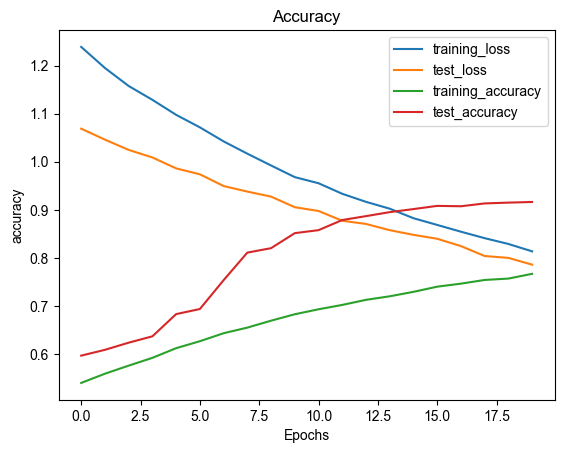

In [5]:
# 讀取數據
data = pd.read_csv('Phishing_Dataset.csv', encoding='utf-8')
features_df = pd.read_csv('Phishing_Dataset1_features.csv')

rs = 1337
lr = 0.000003
ep = 20
model,scaler,X = model(data,features_df,rs,lr,ep)

rs = 1337 lr = 0.000003 ep =30  
accuracy                           0.94     26920   
   macro avg       0.94      0.94      0.94     26920   
weighted avg       0.94      0.94      0.94     26920



In [6]:

def scale_prediction(prediction):

    return prediction * 10.0

# quit()
def predict_url(model, url, scaler):
    # 提取 URL 的特徵
    features = extract_features(url)
    features_df = pd.DataFrame([features])
    # features_df = features_df.drop(columns=['url'])
    # 移除不必要的欄位 'url'
    if 'url' in features_df.columns:
        features_df = features_df.drop(columns=['url'])
    # 對 'tld' 進行 one-hot 編碼
    features_df = pd.get_dummies(features_df, columns=['tld'])
    # 確保列名與訓練模型時的一致，缺失特徵填補為 0
    features_df = features_df.reindex(columns=X.columns, fill_value=0)
    # 進行標準化
    print(features_df)
    features_scaled = scaler.transform(features_df)
    # 預測結果
    raw_prediction = model.predict(features_scaled)[0][0]
    # 將預測結果進行縮放
    scaled_prediction = scale_prediction(raw_prediction)
    # 處理 NAN 的情況
    if np.isnan(scaled_prediction):
        scaled_prediction = 0.0

    return features, scaled_prediction
# 測試網址列表
true_website = []
phishing_website = []

with open("0_testwebsite", 'r', encoding='utf-8') as file:
    test_urls = file.read().split("\n")

# 過濾無效的 URL
urls_to_test = [url for url in test_urls if url and url not in ['True Website', 'Phishing Website', '']]

# 打印預測結果
results = []
for url in urls_to_test:
    features, prediction = predict_url(model, url, scaler)
    result = {
        'url': url,
        'prediction': 'malicious' if prediction < 5.0 else 'benign',  # 分數低於 5.0 的是釣魚網站
        'score': prediction  # 添加預測分數
    }
    result.update(features)  # 更新特徵信息
    results.append(result)
    # print(f"URL: {url}\nPrediction: {result['prediction']}\nScore: {result['score']}\nFeatures: {features}\n")

# 將結果存儲到 CSV
results_df = pd.DataFrame(results)
results_df.to_csv('Phishing_Dataset3_result3.csv', index=False, encoding='utf-8')

# 記錄時間
end_time = time.time()
print(end_time - start_time)

Processing URL: https://www.facebook.com/?locale=zh_TW
Finished processing URL: https://www.facebook.com/?locale=zh_TW
{'url_length': 38, 'domain_length': 16, 'tld': 'com', 'has_ip': 0, 'num_special_chars': 3, 'has_https': 1, 'has_www': 1, 'pct_ext_hyperlinks': 0.9795918367346939, 'pct_ext_resource_urls': 0.015463917525773196, 'ext_favicon': 1, 'num_dots': 2, 'subdomain_level': 1, 'path_level': 1, 'num_dash': 0, 'num_dash_in_hostname': 0, 'at_symbol': 0, 'tilde_symbol': 0, 'num_underscore': 1, 'num_percent': 0, 'num_query_components': 1, 'num_ampersand': 0, 'num_hash': 0, 'num_numeric_chars': 0, 'no_https': 0, 'random_string': 0, 'ip_address': 0, 'domain_in_subdomains': 1, 'domain_in_paths': 0, 'https_in_hostname': 0, 'hostname_length': 16, 'path_length': 1, 'query_length': 12, 'double_slash_in_path': 0, 'num_sensitive_words': 0, 'embedded_brand_name': 1, 'insecure_forms': 0, 'relative_form_action': 1, 'ext_form_action': 1, 'abnormal_form_action': 0}
   url_length  domain_length  has_i

In [7]:
# def adjust_feedback(existing_feedback, adjustment):
#     # 控制feedback的最大/最小值範圍，避免超出邊界
#     max_feedback = 10.0
#     min_feedback = 0.0
    
#     # 根據當前feedback的距離邊界的程度進行調整
#     if adjustment > 0:
#         # 如果反饋是正向的，即用戶認為是安全網站
#         new_feedback = min(existing_feedback + adjustment, max_feedback)
#     else:
#         # 如果反饋是負向的，即用戶認為是釣魚網站
#         new_feedback = max(existing_feedback + adjustment, min_feedback)

#     return new_feedback

In [13]:
# class MyHandler(http.server.SimpleHTTPRequestHandler):
#     def sec_web(self):
#         # 先顯示輸入表單
#             self.send_response(200)
#             self.send_header("Content-type", "text/html")
#             self.end_headers()

#             html_content = """
#             <!DOCTYPE html>
#             <html lang="zh-Hant">
#             <head>
#                 <meta charset="UTF-8">
#                 <meta name="viewport" content="width=device-width, initial-scale=1.0">
#                 <title>簡單輸入表單</title>
#                 <style>
#                     body {
#                         display: flex;
#                         justify-content: center;
#                         align-items: center;
#                         height: 100vh;
#                         margin: 0;
#                         font-family: Arial, sans-serif;
#                     }
#                     .container {
#                         text-align: center;
#                     }
#                     .form-group {
#                         display: flex;
#                         align-items: center;
#                         justify-content: center;
#                     }
#                     input {
#                         padding: 5px;
#                     }
#                 </style>
#             </head>
#             <body>
#                 <div class="container">
#                     <form method="POST">
#                         <h1>這是釣魚網站嗎？(Yes = 1, No = 2, Nothing = 3)</h1>
#                         <input type="text" name="input_field" placeholder="請輸入 1、2 或 3">
#                         <button type="submit">送出</button>
#                     </form>
#                 </div>
#             </body>
#             </html>
#             """
#             self.wfile.write(html_content.encode("utf-8"))
#             # 處理 POST 請求
#             content_length = int(self.headers.get('Content-Length', 0))  # 檢查是否有提供 Content-Length
#             if content_length > 0:
#                 post_data = self.rfile.read(content_length).decode('utf-8')
#                 form_data = parse_qs(post_data)
                
#                 # 檢查是否有有效輸入
#                 user_input_str = form_data.get('input_field', [''])[0].strip()
#                 if user_input_str == '':
#                     print("沒有收到有效輸入，請重新提交。")
#                     return None
                
#                 try:
#                     # 嘗試將輸入轉換為整數
#                     user_input = int(user_input_str)
#                     if user_input not in [1, 2, 3]:
#                         print("輸入無效，請輸入 1、2 或 3")
#                         return 3
#                     print("用戶反饋：" + str(user_input))
#                     return user_input
#                 except ValueError:
#                     print("輸入無效，無法轉換為整數。")
#                     return 3
#             else:
#                 print("沒有收到任何輸入。")
#                 return 3

In [80]:
def adjust_feedback(existing_feedback, adjustment):
    # 控制feedback的最大/最小值範圍，避免超出邊界
    max_feedback = 10.0
    min_feedback = 0.0
    
    # 根據當前feedback的距離邊界的程度進行調整
    if adjustment > 0:
        # 如果反饋是正向的，即用戶認為是安全網站
        new_feedback = min(existing_feedback + adjustment, max_feedback)
    else:
        # 如果反饋是負向的，即用戶認為是釣魚網站
        new_feedback = max(existing_feedback + adjustment, min_feedback)
    return new_feedback

def predict_url_2(model, url, scaler, point):
    flag = False
    final_score = 0.0
    feedback = 0.0
    features = None  
    try:
        # 嘗試讀取現有的結果文件
        results_df = pd.read_csv('Phishing_Dataset3_result1.csv')
        url_in_csv = url in results_df['url'].values
        
        if url_in_csv:
            # URL已存在，根據現有預測結果進行處理
            existing_result = results_df.loc[results_df['url'] == url].iloc[0].to_dict()
            
            # 使用者提供反饋
            input_feedback = point
            print(type(input_feedback))
            if input_feedback == "1":
                # 用戶反饋為釣魚網站，減少 feedback 權重
                new_feedback = adjust_feedback(existing_result['feedback'], -0.5)
                print(1)
            elif input_feedback == "2":
                # 用戶反饋為安全網站，增加 feedback 權重
                new_feedback = adjust_feedback(existing_result['feedback'], 0.5)
                print(2)
            else:
                # 保持 feedback 不變
                new_feedback = existing_result['feedback']
                print(3)
            
            # 更新 feedback 欄位
            results_df.loc[results_df['url'] == url, 'feedback'] = new_feedback

            # 提取特徵並進行重新預測
            features = extract_features(url)
            features_df = pd.DataFrame([features])
            features_df = pd.get_dummies(features_df, columns=['tld'])
            features_df = features_df.reindex(columns=X.columns, fill_value=0)  # 確保使用正確的特徵列
            features_scaled = scaler.transform(features_df)
            raw_prediction = model.predict(features_scaled)[0][0]
            scaled_prediction = scale_prediction(raw_prediction)
            final_score = scaled_prediction * 0.5 + new_feedback * 0.5

            if np.isnan(scaled_prediction):
                scaled_prediction = 0.0

            # 更新新的預測結果
            results_df.loc[results_df['url'] == url, 'score'] = final_score
            results_df.loc[results_df['url'] == url, 'prediction'] = 'malicious' if final_score < 5.0 else 'benign'
            result = results_df.loc[results_df['url'] == url].iloc[0].to_dict()

        else:
            # 如果 URL 不在 CSV 中，進行新預測
            features = extract_features(url)
            features_df = pd.DataFrame([features])
            features_df = pd.get_dummies(features_df, columns=['tld'])
            features_df = features_df.reindex(columns=X.columns, fill_value=0)
            features_scaled = scaler.transform(features_df)
            raw_prediction = model.predict(features_scaled)[0][0]
            scaled_prediction = scale_prediction(raw_prediction)

            if np.isnan(scaled_prediction):
                scaled_prediction = 0.0

            feedback = 5.0
            final_score = scaled_prediction * 0.5 + feedback * 0.5
            result = {
                'url': url,
                'prediction': 'malicious' if final_score < 5.0 else 'benign',
                'score': final_score,
                'feedback': feedback
            }
            result.update(features)

            # 將新記錄加入到 DataFrame 中
            new_result_df = pd.DataFrame([result])
            results_df = pd.concat([results_df, new_result_df], ignore_index=True)

    except FileNotFoundError:
        # 如果 CSV 文件不存在，創建新文件並寫入預測結果
        features = extract_features(url)
        features_df = pd.DataFrame([features])
        features_df = pd.get_dummies(features_df, columns=['tld'])
        features_df = features_df.reindex(columns=X.columns, fill_value=0)
        features_scaled = scaler.transform(features_df)
        raw_prediction = model.predict(features_scaled)[0][0]
        scaled_prediction = scale_prediction(raw_prediction)
        
        if np.isnan(scaled_prediction):
            scaled_prediction = 0.0
            
        feedback = 5.0
        final_score = scaled_prediction * 0.5 + feedback * 0.5
        result = {
            'url': url,
            'prediction': 'malicious' if final_score < 5.0 else 'benign',
            'score': final_score,
            'feedback': feedback
        }
        result.update(features)
        
        # 創建新的 DataFrame
        results_df = pd.DataFrame([result])

    # 最後寫入或更新 CSV 文件
    results_df.to_csv('Phishing_Dataset3_result1.csv', index=False, encoding='utf-8')
    
    if final_score >= 5.0:
        flag = True
    
    return features, final_score, result, flag

In [87]:
PORT = 8000

class MyHandler(http.server.SimpleHTTPRequestHandler):
    def do_GET(self):
        # 回傳表單頁面
        self.send_response(200)
        self.send_header("Content-type", "text/html")
        self.end_headers()

        html_content = """
        <!DOCTYPE html>
        <html lang="zh-Hant">
        <head>
            <meta charset="UTF-8">
            <meta name="viewport" content="width=device-width, initial-scale=1.0">
            <title>簡單輸入表單</title>
            <style>
                body {
                    display: flex;
                    justify-content: center;
                    align-items: center;
                    height: 100vh;
                    margin: 0;
                    font-family: Arial, sans-serif;
                }
                .container {
                    text-align: center;
                }
                .form-group {
                    display: flex;
                    align-items: center;
                    justify-content: center;
                }
                h1 {
                    margin-right: 10px;
                }
                input {
                    padding: 5px;
                }
            </style>
        </head>
        <body>
            <div class="container">
                <div class="form-group">
                    <form method="POST">
                        請輸入文字：<input type="text" name="input_field" placeholder="在此輸入..."><br>
                        這是釣魚網站嗎？(Yes = 1, No = 2, Nothing = 3)<input type="text" name="input_field_2" placeholder="Yes = 1, No = 2, Nothing = 3">
                        <button type="submit">送出</button>
                    </form>
                </div>
            </div>
        </body>
        </html>
        """
        self.wfile.write(html_content.encode("utf-8"))

    def do_POST(self):
        # 取得使用者提交的資料
        content_length = int(self.headers['Content-Length'])
        post_data = self.rfile.read(content_length).decode('utf-8')
        form_data = parse_qs(post_data)

        # 獲取輸入的值
        user_input = form_data.get('input_field', [''])[0]
        phishing_input = form_data.get('input_field_2', [''])[0]

        # 檢查是否有填寫所有必要的欄位
        if not user_input or not phishing_input:
            # 資料不完整，顯示錯誤訊息並提供返回連結
            self.send_response(200)
            self.send_header("Content-type", "text/html")
            self.end_headers()

            response = """
            <!DOCTYPE html>
            <html lang="zh-Hant">
            <head>
                <meta charset="UTF-8">
                <meta name="viewport" content="width=device-width, initial-scale=1.0">
                <title>錯誤</title>
                <style>
                    body {
                        display: flex;
                        justify-content: center;
                        align-items: center;
                        height: 100vh;
                        margin: 0;
                        font-family: Arial, sans-serif;
                    }
                    .container {
                        text-align: center;
                    }
                </style>
            </head>
            <body>
                <div class="container">
                    <h1>資料未填寫完整，請返回並重新填寫。</h1>
                    <a href="/">返回填寫頁面</a>
                </div>
            </body>
            </html>
            """
            self.wfile.write(response.encode("utf-8"))
        else:
            # 資料完整，繼續處理
            point = phishing_input
            input_url = user_input
            if input_url == "exit":
                quit()
            features, prediction, result, flag = predict_url_2(model, input_url, scaler, point)

            # 回傳結果頁面
            self.send_response(200)
            self.send_header("Content-type", "text/html")
            self.end_headers()

            response = f"""
            <!DOCTYPE html>
            <html lang="zh-Hant">
            <head>
                <meta charset="UTF-8">
                <meta name="viewport" content="width=device-width, initial-scale=1.0">
                <title>結果</title>
                <style>
                    body {{
                        display: flex;
                        justify-content: center;
                        align-items: center;
                        height: 100vh;
                        margin: 0;
                        font-family: Arial, sans-serif;
                    }}
                    .container {{
                        text-align: center;
                    }}
                </style>
            </head>
            <body>
                <div class="container">
                    <h1>你輸入的是: {user_input}</h1>
                    <h1>這網址是: {flag}</h1>
                    <h1>分數是: {format(prediction, ".2f")}</h1>
                    <a href="/">返回</a>
                </div>
            </body>
            </html>
            """
            self.wfile.write(response.encode("utf-8"))

# 啟動伺服器
with socketserver.TCPServer(("", PORT), MyHandler) as httpd:
    print(f"伺服器正在執行於 http://localhost:{PORT}")
    httpd.serve_forever()

伺服器正在執行於 http://localhost:8000


127.0.0.1 - - [20/Oct/2024 00:54:52] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [20/Oct/2024 00:54:52] "GET /favicon.ico HTTP/1.1" 200 -
127.0.0.1 - - [20/Oct/2024 00:54:55] "POST / HTTP/1.1" 200 -
127.0.0.1 - - [20/Oct/2024 00:54:55] "GET /favicon.ico HTTP/1.1" 200 -
127.0.0.1 - - [20/Oct/2024 00:54:57] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [20/Oct/2024 00:54:57] "GET /favicon.ico HTTP/1.1" 200 -


KeyboardInterrupt: 